# CTIP quickstart — from an image to measurements (no GPU, no dataset)

This notebook walks through the parts of CTIP that work **without a trained model**:

1. image quality (focus) — reject blurry frames before labelling
2. optical colour features and the rule-based maturity baseline
3. pixel → µm scale
4. a leakage-safe, session-grouped dataset split

> **The images are synthetic** (`data/images/test_synthetic/`, rendered for tests). They are not real trichomes and
> the numbers below say nothing about real plants. CTIP ships no trained trichome detector yet — see the README.
> Maturity here is an *optical* observation; it is never a cannabinoid (THC/CBD) measurement.

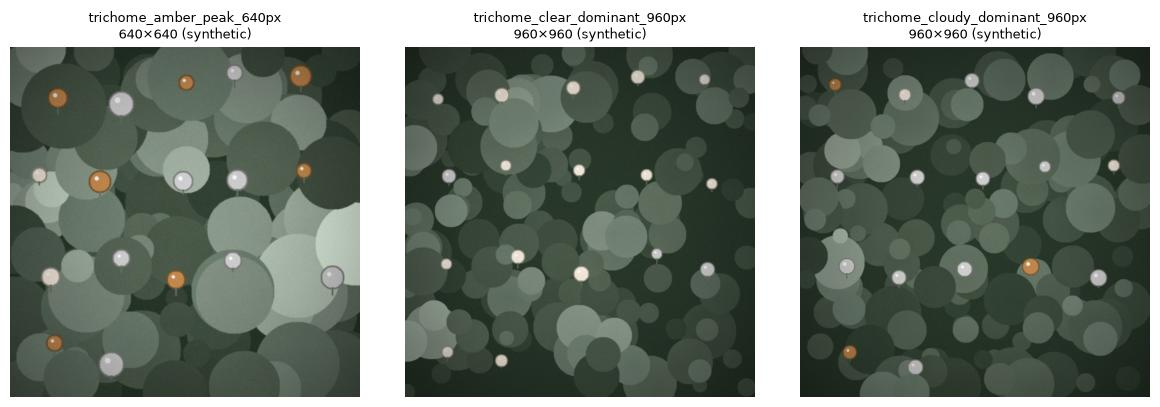

In [1]:
%config InlineBackend.figure_format = "jpeg"
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
images = {p.stem: cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
          for p in sorted((ROOT / "data/images/test_synthetic").glob("*.png"))}
fig, axes = plt.subplots(1, len(images), figsize=(12, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img); ax.set_title(f"{name}\n{img.shape[1]}×{img.shape[0]} (synthetic)", fontsize=9); ax.axis("off")
plt.tight_layout()

## 1 · Focus: keep only sharp frames

A composite of Laplacian variance, Tenengrad, normalised variance and FFT energy. Blurring the same image must lower
the score — that is the property the filter relies on. The quality labels (`good`, `unusable`, …) use thresholds
tuned for real micrographs; the flat synthetic renders score low in absolute terms, so compare sharp vs blurred.

In [2]:
from focus.metrics.composite import compute_focus_score

for name, img in images.items():
    sharp = compute_focus_score(img)
    blurred = compute_focus_score(cv2.GaussianBlur(img, (0, 0), 3))
    print(f"{name:32s} sharp {sharp.composite:6.3f} ({sharp.quality_label:>9s})   blurred {blurred.composite:6.3f} ({blurred.quality_label})")

trichome_amber_peak_640px        sharp  0.186 ( unusable)   blurred  0.153 (unusable)
trichome_clear_dominant_960px    sharp  0.182 ( unusable)   blurred  0.153 (unusable)
trichome_cloudy_dominant_960px   sharp  0.181 ( unusable)   blurred  0.152 (unusable)


## 2 · Optical maturity: colour features and the rule-based baseline

`rule_based_maturity_estimate` is a heuristic baseline (and fallback) on HSV/LAB colour of a trichome head. Its
thresholds are approximate and depend on lighting and white balance — calibrate them on labelled images from your own
microscope before trusting them.

Text(0.5, 1.0, "rule-based optical maturity per head (synthetic image; 'unknown' = baseline not confident)")

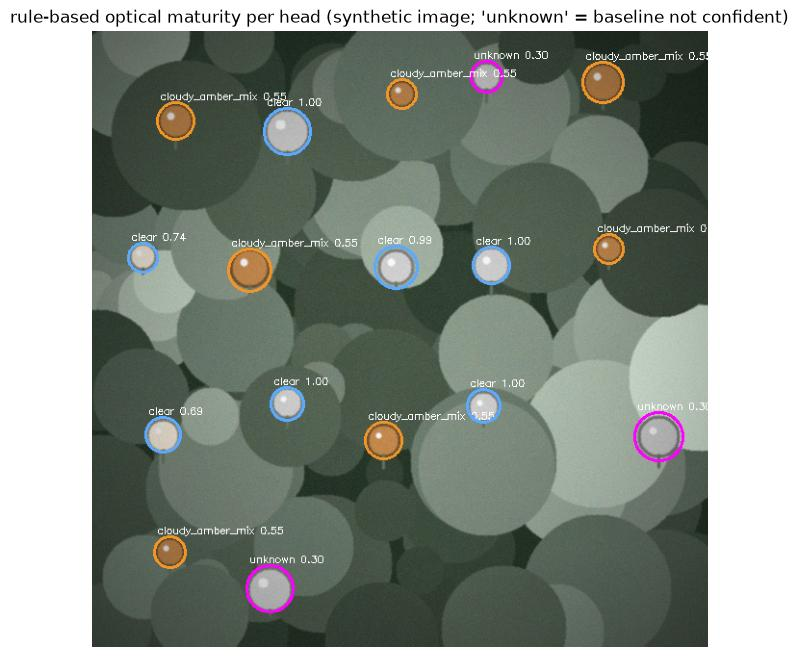

In [3]:
from maturity.domain.color_features import extract_color_features, rule_based_maturity_estimate

img = images["trichome_amber_peak_640px"]
gray = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), 3)
# stand-in for the detector: round glandular heads via a Hough transform (a trained YOLO11 model does this in CTIP)
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1.2, 25, param1=80, param2=22, minRadius=8, maxRadius=24)[0]

COLOURS = {"clear": (90, 170, 255), "cloudy": (240, 240, 240), "cloudy_amber_mix": (240, 150, 40), "amber": (200, 90, 0)}
overlay = img.copy()
for x, y, r in circles.round().astype(int):
    m = r + 4
    y0, x0 = max(0, y - m), max(0, x - m)
    crop = img[y0:y + m, x0:x + m]
    yy, xx = np.mgrid[0:crop.shape[0], 0:crop.shape[1]]
    head = (yy - (y - y0)) ** 2 + (xx - (x - x0)) ** 2 <= (r - 2) ** 2      # analyse the head only, not the stalk
    stage, conf = rule_based_maturity_estimate(extract_color_features(crop, head))
    cv2.circle(overlay, (x, y), r + 3, COLOURS.get(stage.value, (255, 0, 255)), 2)
    cv2.putText(overlay, f"{stage.value} {conf:.2f}", (x - r, y - r - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1)

plt.figure(figsize=(8, 8)); plt.imshow(overlay); plt.axis("off")
plt.title("rule-based optical maturity per head (synthetic image; 'unknown' = baseline not confident)")

## 3 · Pixel → µm

The objective-based estimate is only approximate (±20–30 %). For measurements, calibrate with a stage micrometer
(`trichome calibrate run`).

In [4]:
from measurement.calibration.stage_micrometer import estimate_scale_from_objective

profile = estimate_scale_from_objective(objective_magnification=40, sensor_pixel_size_um=2.4)
print(profile)

MicroscopeProfile('40× objective estimate', 0.0600 µm/px ±25.0%, method=objective_estimate)


## 4 · A dataset split that does not leak

Frames from one imaging session are near-duplicates. If they end up in both train and test, the test score measures
memory, not generalisation. CTIP assigns whole sessions to one split (session from `data.session`, the image folder or
the file-name series) and warns when it cannot tell sessions apart.

In [5]:
from training.pipelines.session_split import session_key, split_by_session

tasks = [{"id": i, "data": {"image": f"/data/local-files/?d=scope/plant{i // 6}_slide1/frame_{i % 6:04d}.jpg"}}
         for i in range(60)]                     # 10 sessions × 6 frames
split = split_by_session(tasks, train_ratio=0.7, val_ratio=0.15, seed=42)
print(split.summary())
keys = {s: {session_key(t)[0] for t in split.splits[s]} for s in split.splits}
assert not (keys["train"] & keys["val"] or keys["train"] & keys["test"] or keys["val"] & keys["test"])
print("no session appears in two splits ✓")

train: 42 images / 7 sessions  val: 12 images / 2 sessions  test: 6 images / 1 sessions
no session appears in two splits ✓


## Next steps

- Collect images from **several sessions** with one microscope setup and consistent lighting.
- Label them in Label Studio (VLM pre-labels are optional and always reviewed).
- Export with `POST /api/v1/training/prepare-ls-dataset` and train: `trichome train start --data dataset.yaml`.
- Evaluate (mAP, calibration, failure cases) before using any number.

Contributing open, well-documented images helps everyone — see `CONTRIBUTING.md` and
`docs/templates/dataset_card.md`.